# Phytoplankton size structure in the Weddell Sea

This notebook accompanies the manuscript by Brewin et al., "Phytoplankton size structure in the northwestern Weddell Sea". It illustrates how the data were processed, the models were fitted, and the key figures (Figures 1–5) were generated. Figure 1 does not include the background bathymetry or ice shelf layer, and Figure 6 is not included in this notebook. Both figures require large datasets (bathymetry, ice shelf and satellite) that could not be uploaded to GitHub because of file size limitations. If you are interested in reproducing these figures or accessing the associated code, please contact the corresponding author.

## Step 1: Import packages needed for the notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
import string
import geopandas as gpd
import warnings
import rasterio
import os
import zipfile
import glob
from lmfit import Minimizer, Parameters, report_fit
from scipy import stats
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import median_absolute_error
from rasterio.plot import plotting_extent
from rasterio.warp import calculate_default_transform, reproject, Resampling
warnings.filterwarnings('ignore')

## Step 2: Functions used in the notebook

In [2]:
### Statistical metrics
def errortest_log(x, y):
    x = np.log10(x).replace([np.inf, -np.inf], np.nan)
    y = np.log10(y).replace([np.inf, -np.inf], np.nan)
    z = pd.concat([x, y], axis = 1).dropna()
    [correlation, p] = stats.pearsonr(z.iloc[:,0],z.iloc[:,1])
    diff = z.iloc[:,1]-z.iloc[:,0]
    bias = sum(diff)/diff.count()
    mae_mean = mean_absolute_error(z.iloc[:,0], z.iloc[:,1])
    rmse = np.sqrt(mean_squared_error(z.iloc[:,0], z.iloc[:,1]))
    n = len(z)
    mae_median = median_absolute_error(z.iloc[:,0], z.iloc[:,1])
    rmse_cp_mean = np.sqrt(np.nanmean(np.power(((z.iloc[:,1]-np.nanmean(z.iloc[:,1]))-(z.iloc[:,0]-np.nanmean(z.iloc[:,0]))),2)))
    rmse_cp_median = np.sqrt(np.nanmedian(np.power(((z.iloc[:,1]-np.nanmedian(z.iloc[:,1]))-(z.iloc[:,0]-np.nanmedian(z.iloc[:,0]))),2)))
    slope, intercept, r_value, p_value, std_err = stats.linregress(z.iloc[:,0], z.iloc[:,1])
    result = correlation, p, bias, mae_mean, rmse, n, mae_median, rmse_cp_mean, rmse_cp_median, slope, intercept
    return result

### Ocean Colour algorithms
def oc4_seawifs_OW_2019(ratio):
    # MBR = Rrs(443 > 490 > 510)/Rrs555; 0.32814; −3.20725; 3.22969; −1.36769; −0.81739
    chla_log10 = 0.32814\
                -3.20725*np.log10(ratio)\
                +3.22969*np.log10(ratio)*np.log10(ratio)\
                -1.36769*np.log10(ratio)*np.log10(ratio)*np.log10(ratio)\
                -0.81739*np.log10(ratio)*np.log10(ratio)*np.log10(ratio)*np.log10(ratio)
    chla = np.power(10,chla_log10)
    return chla

def oc4_seawifs_Johnson_2013(ratio):
    # MBR = Rrs(443 > 490 > 510)/Rrs555; 0.6736, -2.0714, -0.4939, 0.4756
    chla_log10 = 0.6736\
                -2.0714*np.log10(ratio)\
                -0.4939*np.log10(ratio)*np.log10(ratio)\
                +0.4756*np.log10(ratio)*np.log10(ratio)*np.log10(ratio)
    chla = np.power(10,chla_log10)
    return chla

def oc4_seawifs_Ferreira_2022(ratio):
    # MBR = Rrs(443 > 490 > 510)/Rrs555
    chla = pd.Series(np.nan, index=ratio.index)
    for i in range(0, len(ratio), 1):
        r = ratio.iloc[i]
        if r < 3:
            chla_log10 = 0.60159\
                        -3.20362*np.log10(r)\
                        +11.17268*np.log10(r)*np.log10(r)\
                        -26.78898*np.log10(r)*np.log10(r)*np.log10(r)\
                        +18.64112*np.log10(r)*np.log10(r)*np.log10(r)*np.log10(r)
            chla.iloc[i] = np.power(10, chla_log10)
        elif r > 5:
            chla_log10 = 0.63668\
                        -1.94561*np.log10(r)\
                        +0.15707*np.log10(r)*np.log10(r)\
                        -0.5716*np.log10(r)*np.log10(r)*np.log10(r)
            chla.iloc[i] = np.power(10, chla_log10)
        else:
            chla_log10_a = 0.60159\
                        -3.20362*np.log10(r)\
                        +11.17268*np.log10(r)*np.log10(r)\
                        -26.78898*np.log10(r)*np.log10(r)*np.log10(r)\
                        +18.64112*np.log10(r)*np.log10(r)*np.log10(r)*np.log10(r)
            chla_log10_b = 0.63668\
                        -1.94561*np.log10(r)\
                        +0.15707*np.log10(r)*np.log10(r)\
                        -0.5716*np.log10(r)*np.log10(r)*np.log10(r)
            chla.iloc[i] = np.power(
                10,
                (1-(r-3)/2)*chla_log10_a + (r-3)/2*chla_log10_b)
    return chla

### Definition for validation panels
def plot_validation(ax, chl, model, title, label):
    ax.scatter(chl['sff'], model['sff'],
               facecolors='yellowgreen', edgecolors='darkgreen',
               alpha=0.6, s=40, label='SFF', marker = '^')
    ax.scatter(chl['hplc'], model['hplc'],
               facecolors='pink', edgecolors='deeppink',
               alpha=0.6, s=40, label='HPLC', marker = 'o')
    ax.plot(xlim, ylim, '--', color='0.7')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Measured Chl-$a$ (mg m$^{-3}$)', fontsize=10)
    ax.set_ylabel('Retrieved Chl-$a$ (mg m$^{-3}$)', fontsize=10)

### Three component model function
def Three_com_mod_PICO(params1, X, Y):
    P1 = params1['Cm1']
    P2 = params1['D1']
    model = (P1*(1-np.exp(-(P2/P1)*Y)))/Y 
    return(model-X)

### Three component model function
def Three_com_mod_NANOPICO(params1, X, Y):
    P1 = params1['Cm12']
    P2 = params1['D12']
    model = (P1*(1-np.exp(-(P2/P1)*Y)))/Y
    return(model-X)

## Step 3: Load PICCOLO SFF-based matched dataset

In [3]:
df = pd.read_excel('PICCOLO_SFF_HPLC_Rrs_0527.xlsx', sheet_name='SFF') 
# Create the Labels column for defining Larsen, Shelf and Transect samples
df["Labels"] = df["Station_Xuerong"].map({
    "Test2": 1,
    "Mooring1/Mooring1_part_2/Mooring1_part_3": 1,
    "Mooring1/Mooring1_part_5": 1,   
    "N96": 2,
    "N104_second": 2,
    "SS2": 1,   
    "SS4": 1, 
    "T1": 3, 
    "T2/T2_part_2": 3, 
    "T3": 3, 
    "T4/T4_part_1": 3, 
    "T5/T5_part_1": 3, 
    "T6/T6_part_2": 3,     
    "T7": 3,      
    "T8/T8_part_2": 3,          
    "Mooring2/Mooring2_part_1": 1,
    "IceStation1/IceStation1_part_2": 1,
    "Supersite/Supersite_part_1": 1
})

## Step 4: Load PICCOLO HPLC-based dataset

In [4]:
df_hplc = pd.read_excel('Data_Github/PICCOLO.xlsx', sheet_name='HPLC') 

## Step 5: Load Rothera SFF data

In [5]:
### Read ROTHERA data
df_ROTH = pd.read_csv('Data_Github/ROTHERA.csv', header = 0)
DATE_ROTHERA         = df_ROTH.loc[:,'DATE (YYYY-MM-DD)'].to_numpy()
MICRO_CHL_ROTHERA    = df_ROTH.loc[:,'MEAN_CHLA_MP'].to_numpy()
NANO1_CHL_ROTHERA    = df_ROTH.loc[:,'MEAN_CHLA_NP'].to_numpy()
NANO2_CHL_ROTHERA    = df_ROTH.loc[:,'MEAN_CHLA_UP'].to_numpy()
NANO_CHL_ROTHERA     = NANO1_CHL_ROTHERA + NANO2_CHL_ROTHERA
PICO_CHL_ROTHERA     = df_ROTH.loc[:,'MEAN_CHLA_PP'].to_numpy()
TOTAL_CHL_ROTHERA    = df_ROTH.loc[:,'TOTAL_CHLA (mg m-3)'].to_numpy()
QC_XUERONG           = df_ROTH.loc[:,'QC-XUERONG'].to_numpy()
DEPTH_ROTHERA        = np.full(MICRO_CHL_ROTHERA.shape, 15.0)
LAT_ROTHERA          = np.full(MICRO_CHL_ROTHERA.shape, -67.56888889)
LON_ROTHERA          = np.full(MICRO_CHL_ROTHERA.shape, -68.12472222)
## Quality control based on QC by Xuerong
ASD = np.where(QC_XUERONG > 0)
DATE_ROTHERA         = DATE_ROTHERA[ASD]
LAT_ROTHERA          = LAT_ROTHERA[ASD]
LON_ROTHERA          = LON_ROTHERA[ASD]
MICRO_CHL_ROTHERA    = MICRO_CHL_ROTHERA[ASD]
NANO_CHL_ROTHERA     = NANO_CHL_ROTHERA[ASD]
PICO_CHL_ROTHERA     = PICO_CHL_ROTHERA[ASD]
TOTAL_CHL_ROTHERA    = TOTAL_CHL_ROTHERA[ASD]
DEPTH_ROTHERA        = DEPTH_ROTHERA[ASD]

## Step 6: Load AMT SFF data

In [6]:
### Read AMT data
df_AMT = pd.read_csv('Data_Github/AMT.csv', header=0, na_values=-999)
AMT              = df_AMT.loc[:,'AMT transect'].to_numpy()
LAT_AMT          = df_AMT.loc[:,'Latitude'].to_numpy()
LON_AMT          = df_AMT.loc[:,'Longitude'].to_numpy()
MICRO_CHL_AMT    = df_AMT.loc[:,'CHL (>20 micron) (mg/m^3)'].to_numpy()
NANO_CHL_AMT     = df_AMT.loc[:,'CHL (2-20 micron) (mg/m^3)'].to_numpy()
PICO_CHL_AMT     = df_AMT.loc[:,'CHL (0.2-2 micron) (mg/m^3)'].to_numpy()
TOTAL_CHL_AMT    = df_AMT.loc[:,'CHL (sum of fractions) (mg/m^3)'].to_numpy()
DEPTH_AMT        = df_AMT.loc[:,'Sample depth'].to_numpy()
## Basic QC Total Chl-a > 0
ASD = np.where(TOTAL_CHL_AMT > 0)
AMT              = AMT[ASD]
LAT_AMT          = LAT_AMT[ASD]
LON_AMT          = LON_AMT[ASD]
MICRO_CHL_AMT    = MICRO_CHL_AMT[ASD]
NANO_CHL_AMT     = NANO_CHL_AMT[ASD]
PICO_CHL_AMT     = PICO_CHL_AMT[ASD]
TOTAL_CHL_AMT    = TOTAL_CHL_AMT[ASD]
DEPTH_AMT        = DEPTH_AMT[ASD]

## Step 7: Figure 1 Map of data

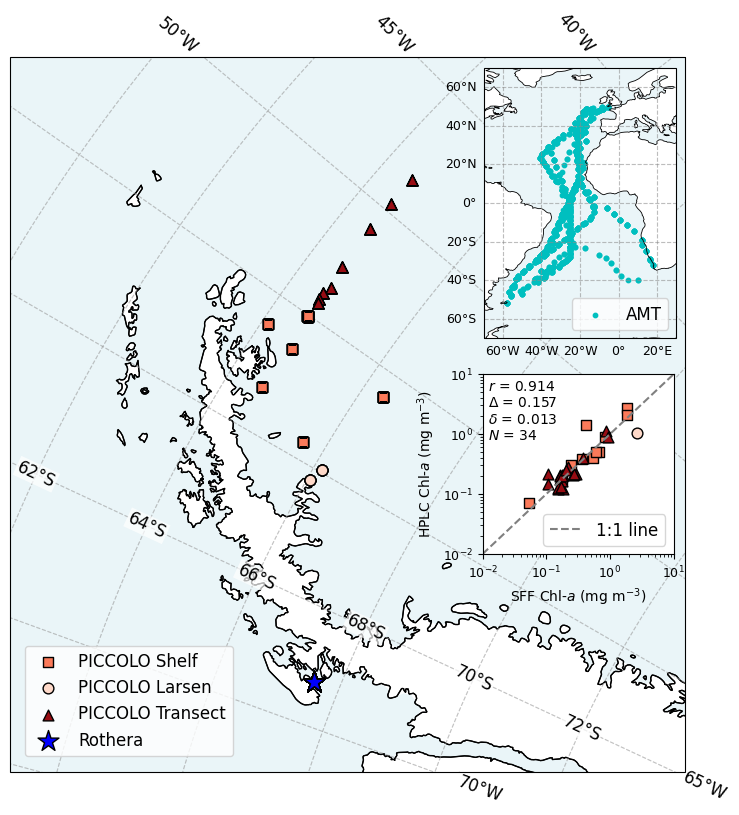

In [7]:
## SET UP FIGURE
fig = plt.figure(figsize=(7.5, 9))

## MAIN PANEL: ANTARCTICA
ax_main = plt.axes(projection=ccrs.SouthPolarStereo())
ax_main.set_extent([-70, -46.5, -70, -62.5], crs=ccrs.PlateCarree())

## OCEAN BACKGROUND
ax_main.add_feature(cfeature.OCEAN, facecolor="lightblue", alpha=0.25, zorder=0)
land = cfeature.NaturalEarthFeature("physical","land", "10m", edgecolor="k", facecolor="w")
ax_main.add_feature(land, zorder=1)
ax_main.coastlines(resolution="10m", linewidth=0.8)
ax_main.gridlines(draw_labels=False, linestyle="--", alpha=0.4)

## PICCOLO LABELS FOR Self, Larsen, Transect
cmap = mpl.cm.Reds
label_colors = {1: cmap(0.45), 2: cmap(0.15), 3: cmap(0.90)}
label_names = {1: "PICCOLO Shelf", 2: "PICCOLO Larsen", 3: "PICCOLO Transect"}
marker_names = {1: "s", 2: "o", 3: "^"}
for lab, color in label_colors.items():
    subset = df[df["Labels"] == lab]
    ax_main.scatter(subset["lon"], subset["lat"],transform=ccrs.PlateCarree(),
        marker=marker_names[lab], color=color, edgecolor = 'k', s=60, zorder=10, label=label_names[lab])
    
## ROTHERA
ax_main.scatter(LON_ROTHERA,LAT_ROTHERA,transform=ccrs.PlateCarree(),marker="*",color="blue",edgecolor = 'k',
    s=250,zorder=11, label="Rothera")

## GRIDLINES
gl2 = ax_main.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color='gray',alpha=0.3,linestyle='--')
gl2.xlabel_style = {'size': 12}
gl2.ylabel_style = {'size': 12}
lat_ticks = [-72, -70, -68, -66, -64, -62]   
for lat in lat_ticks:
    ax_main.text(-65,lat,f"{abs(lat):.0f}°S",transform=ccrs.PlateCarree(),fontsize=12,
        ha="center",va="center",rotation=-25,                    
        bbox=dict(facecolor="white",edgecolor="none",alpha=0.7,pad=1),zorder=20)
    
## PLOT AMT ATLANTIC DATA INSET
ax_small = plt.axes([0.66, 0.60, 0.3, 0.3],projection=ccrs.PlateCarree())
ax_small.set_extent([-70, 30, -70, 70], crs=ccrs.PlateCarree())
## OCEAN BACKGROUND
ax_small.add_feature(cfeature.OCEAN, facecolor="lightblue", alpha=0.25, zorder=0)
ax_small.add_feature(cfeature.LAND, facecolor="w")
ax_small.coastlines(resolution="110m", linewidth=0.6)
ax_small.gridlines(alpha=0.3, linestyle="--")
## AMT DATA
ax_small.scatter(LON_AMT,LAT_AMT,transform=ccrs.PlateCarree(),color="c",s=10,label="AMT")
## GRIDLINES
gl1 = ax_small.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color='gray',
                         alpha=0.4,linestyle='--')
gl1.top_labels = False
gl1.right_labels = False
gl1.xlabel_style = {'size': 9}
gl1.ylabel_style = {'size': 9}
gl1.xpadding = 5
gl1.ypadding = 5

## PLOT PICCOLO CHL_A SCATTER INSET
## Error stats
error_total = errortest_log(df['total_chla_sff'],df['total_chla_hplc'])
xx = np.arange(0.01, 10, 0.1)
ax_small2 = plt.axes([0.68, 0.36, 0.255, 0.20])
ax_small2.set_facecolor('white')        
for lab, color in label_colors.items():
    subset = df[df["Labels"] == lab]
    ax_small2.scatter(subset['total_chla_sff'],subset['total_chla_hplc'],marker=marker_names[lab],
        color=color,edgecolor = 'k',s=60)
ax_small2.plot(xx, xx, '--', color='grey', label = '1:1 line')
ax_small2.set_xscale('log')
ax_small2.set_yscale('log')
ax_small2.set_xlim([0.01, 10])
ax_small2.set_ylim([0.01, 10])
ax_small2.tick_params(labelsize=9)
## Statistics text
text = (f"$r$ = {error_total[0]:.3f}\n"
    f"$\\Delta$ = {error_total[7]:.3f}\n"
    f"$\\delta$ = {error_total[2]:.3f}\n"
    f"$N$ = {int(error_total[5])}")
ax_small2.annotate(text,xy=(0, 1),xycoords='axes fraction',xytext=(4, -4),textcoords='offset points',
    ha='left',va='top',fontsize=10)
ax_small2.set_xlabel('SFF Chl-$a$ ($\\mathregular{mg\\ m^{-3}}$)',fontsize=10)
ax_small2.set_ylabel('HPLC Chl-$a$ ($\\mathregular{mg\\ m^{-3}}$)',fontsize=10)

## LEGENDS
ax_main.legend(loc="center left",bbox_to_anchor=(0.01, 0.1),ncol=1,fontsize=12)
ax_small.legend(loc="lower right",ncol=1,fontsize=12)
ax_small2.legend(loc="lower right",ncol=1,fontsize=12)

## SPACING AND SHOW PLOT
plt.subplots_adjust(left=0.05,right=0.95,top=0.95,bottom=0.08)
plt.show()

## Step 8: Figure 2 Compare DPA-derived Chl-a with HPLC Chl-a

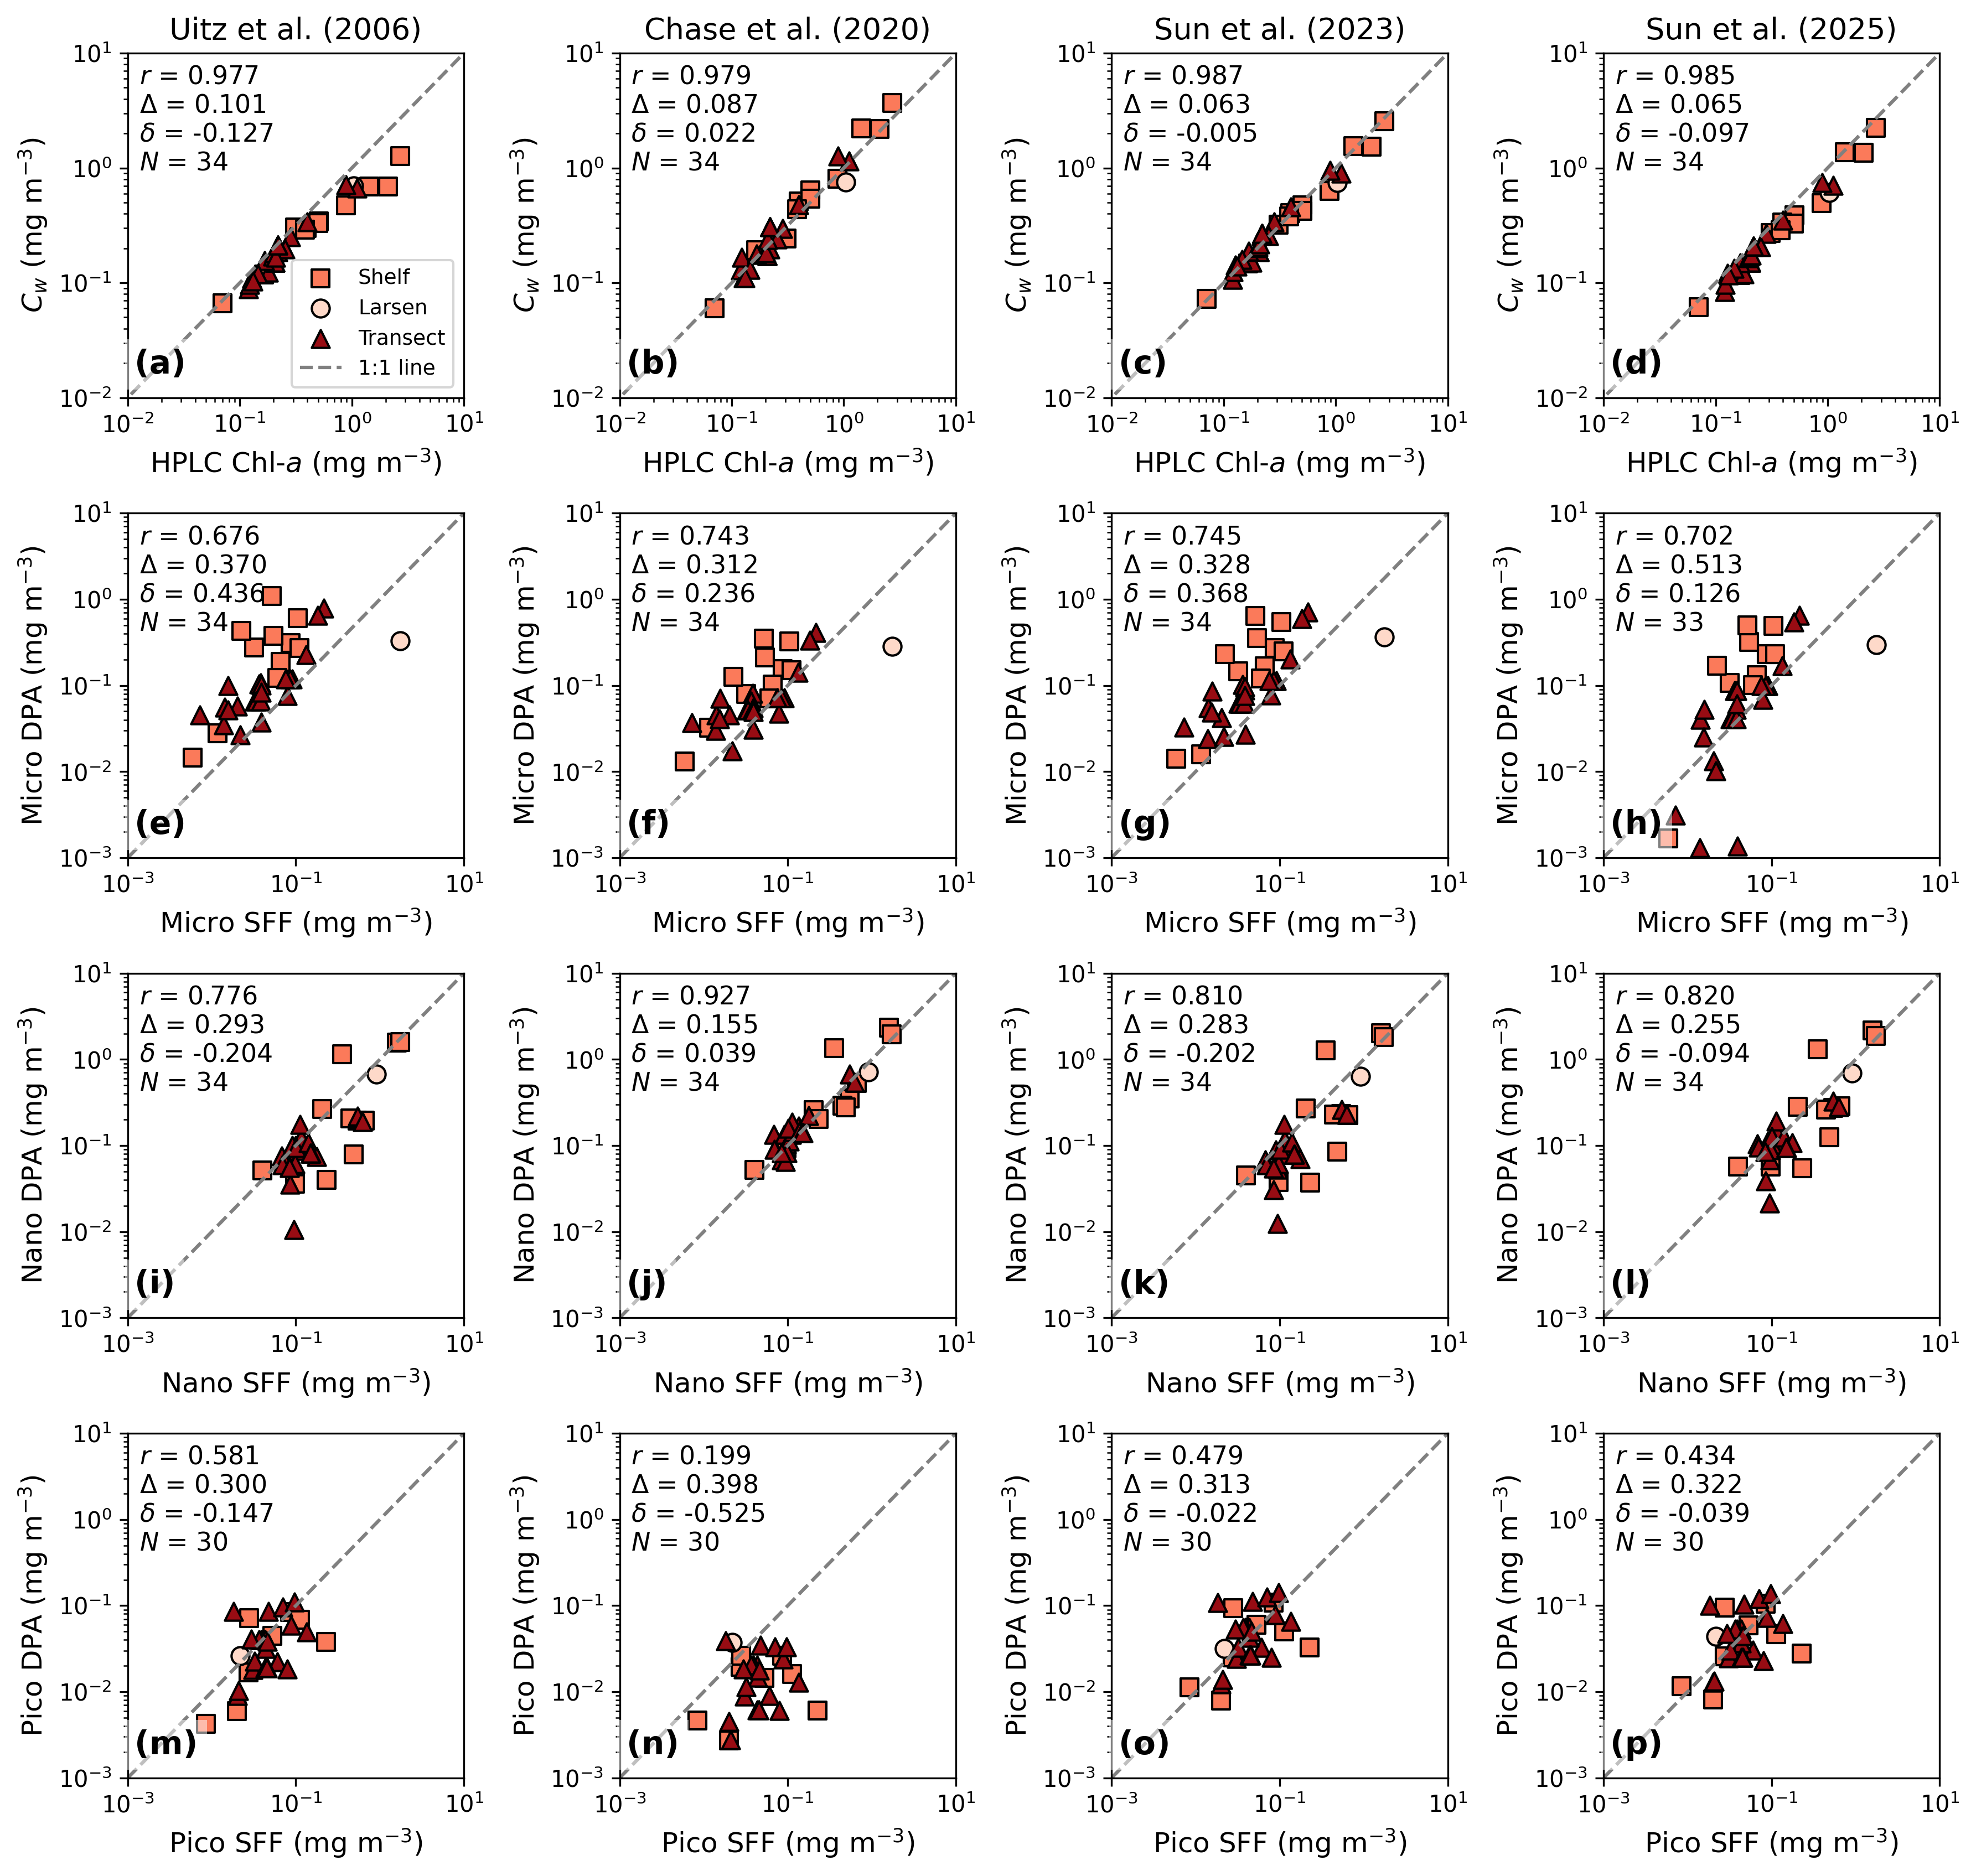

In [8]:
## LABEL STYLE AND NAMES
cmap = mpl.cm.Reds
label_colors = {1: cmap(0.45),2: cmap(0.15),3: cmap(0.90)}
label_names = {1: "Shelf",2: "Larsen",3: "Transect"}
marker_names = {1: "s",2: "o",3: "^"}

## PREPARE X RANGES
xx_cw = np.arange(0.01, 100, 0.1)
xx_dpa = np.arange(0.001, 10, 0.1)

## COMPUTE STATISTICS FOR CW COMPARISON
df_cw = df[['total_chla_hplc','DPw_uitz2006','DPw_chase2020','DPw_sun2023','DPw_sun2025_SO','Labels']]
error_uitz2006 = errortest_log(df_cw['total_chla_hplc'], df_cw['DPw_uitz2006'])
error_chase2020 = errortest_log(df_cw['total_chla_hplc'], df_cw['DPw_chase2020'])
error_sun2023 = errortest_log(df_cw['total_chla_hplc'], df_cw['DPw_sun2023'])
error_sun2025_SO = errortest_log(df_cw['total_chla_hplc'], df_cw['DPw_sun2025_SO'])
cw_configs = [('DPw_uitz2006',    error_uitz2006,    'Uitz et al. (2006)'),
              ('DPw_chase2020',   error_chase2020,   'Chase et al. (2020)'),
            ('DPw_sun2023',     error_sun2023,     'Sun et al. (2023)'),
              ('DPw_sun2025_SO',  error_sun2025_SO,  'Sun et al. (2025)')]

## DPA CONFIGURATION
methods = [('uitz2006','Uitz et al. (2006)'),('chase2020','Chase et al. (2020)'),
           ('sun2023','Sun et al. (2023)'),('sun2025_SO', 'Sun et al. (2025)')]
sizes = [('micro','micro_chla_sff'),('nano','nano_chla_sff'),('pico','pico_chla_sff')]

## SETUP 4 x 4 FIGURE
fig, axes = plt.subplots(nrows=4,ncols=4,figsize=(12, 12),dpi=300)

## LETTERS FOR PLOTS
panel_labels = list(string.ascii_lowercase)

## FIGURE ROW 0: CW COMPARISON
for j, (col, err, title) in enumerate(cw_configs):
    ax = axes[0, j]
    for lab in label_colors.keys():
        subset = df_cw[df_cw["Labels"] == lab]
        ax.scatter(subset['total_chla_hplc'],subset[col],s=60,marker=marker_names[lab],
            color=label_colors[lab],edgecolor = 'k',label=label_names[lab])
    ax.plot(xx_dpa, xx_dpa, '--', color='grey', label = '1:1 line')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim([0.01, 10])
    ax.set_ylim([0.01, 10])
    ax.tick_params(labelsize=10)
    text = (f"$r$ = {err[0]:.3f}\n" f"$\\Delta$ = {err[7]:.3f}\n" f"$\\delta$ = {err[2]:.3f}\n"
            f"$N$ = {int(err[5])}")
    ax.annotate(text,xy=(0, 1),xycoords='axes fraction',xytext=(5, -5),textcoords='offset points',
        ha='left',va='top',fontsize=11)
    ax.set_title(title, fontsize=13)
    ax.set_ylabel('$C_w$ ($\\mathregular{mg\\ m^{-3}}$)', fontsize=12)
    ax.set_xlabel('HPLC Chl-$a$ ($\\mathregular{mg\\ m^{-3}}$)', fontsize=12)
    ax.text(0.02, 0.05,f"({panel_labels[j]})",transform=ax.transAxes,fontsize=14,
        fontweight='bold',va='bottom',ha='left',bbox=dict(facecolor='white', edgecolor='none', alpha=0.5))

## FIGURE ROWS 1-3: DPA 
## LETTERS FOR _PLOTS
panel_labels = list(string.ascii_lowercase[4:])  # starts at 'e'
## LABELS
panel_idx = 0
for i, (size_name, sff_col) in enumerate(sizes, start=1):
    for j, (method_key, method_title) in enumerate(methods):
        ax = axes[i, j]
        dpa_col = f'{size_name}_chla_{method_key}'
        err = errortest_log(df[sff_col], df[dpa_col])
        for lab in label_colors.keys():
            subset = df[df["Labels"] == lab]
            ax.scatter(subset[sff_col],subset[dpa_col],s=60,marker=marker_names[lab],
                color=label_colors[lab],edgecolor = 'k',label=label_names[lab])
        ax.plot(xx_dpa, xx_dpa, '--', color='grey')
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlim([0.001, 10])
        ax.set_ylim([0.001, 10])
        ax.tick_params(labelsize=10)
        text = (f"$r$ = {err[0]:.3f}\n" f"$\\Delta$ = {err[7]:.3f}\n" f"$\\delta$ = {err[2]:.3f}\n"
            f"$N$ = {int(err[5])}")
        ax.annotate(text,xy=(0, 1),xycoords='axes fraction',xytext=(5, -5),textcoords='offset points',
            ha='left',va='top',fontsize=11)
        ax.set_ylabel(f'{size_name.capitalize()} DPA ' '($\\mathregular{mg\\ m^{-3}}$)',fontsize=12)
        ax.set_xlabel(f'{size_name.capitalize()} SFF ' '($\\mathregular{mg\\ m^{-3}}$)',fontsize=12)
        ax.text(0.02, 0.05,f"({panel_labels[panel_idx]})",transform=ax.transAxes,fontsize=14,
            fontweight='bold',va='bottom',ha='left',bbox=dict(facecolor='white', edgecolor='none', alpha=0.5))
        panel_idx += 1   
axes[0, 0].legend(loc="lower right",ncol=1,fontsize=9)

## LAYOUT
fig.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

## STEP 9: Figure 3 Band-ratio Chl-a algorithms

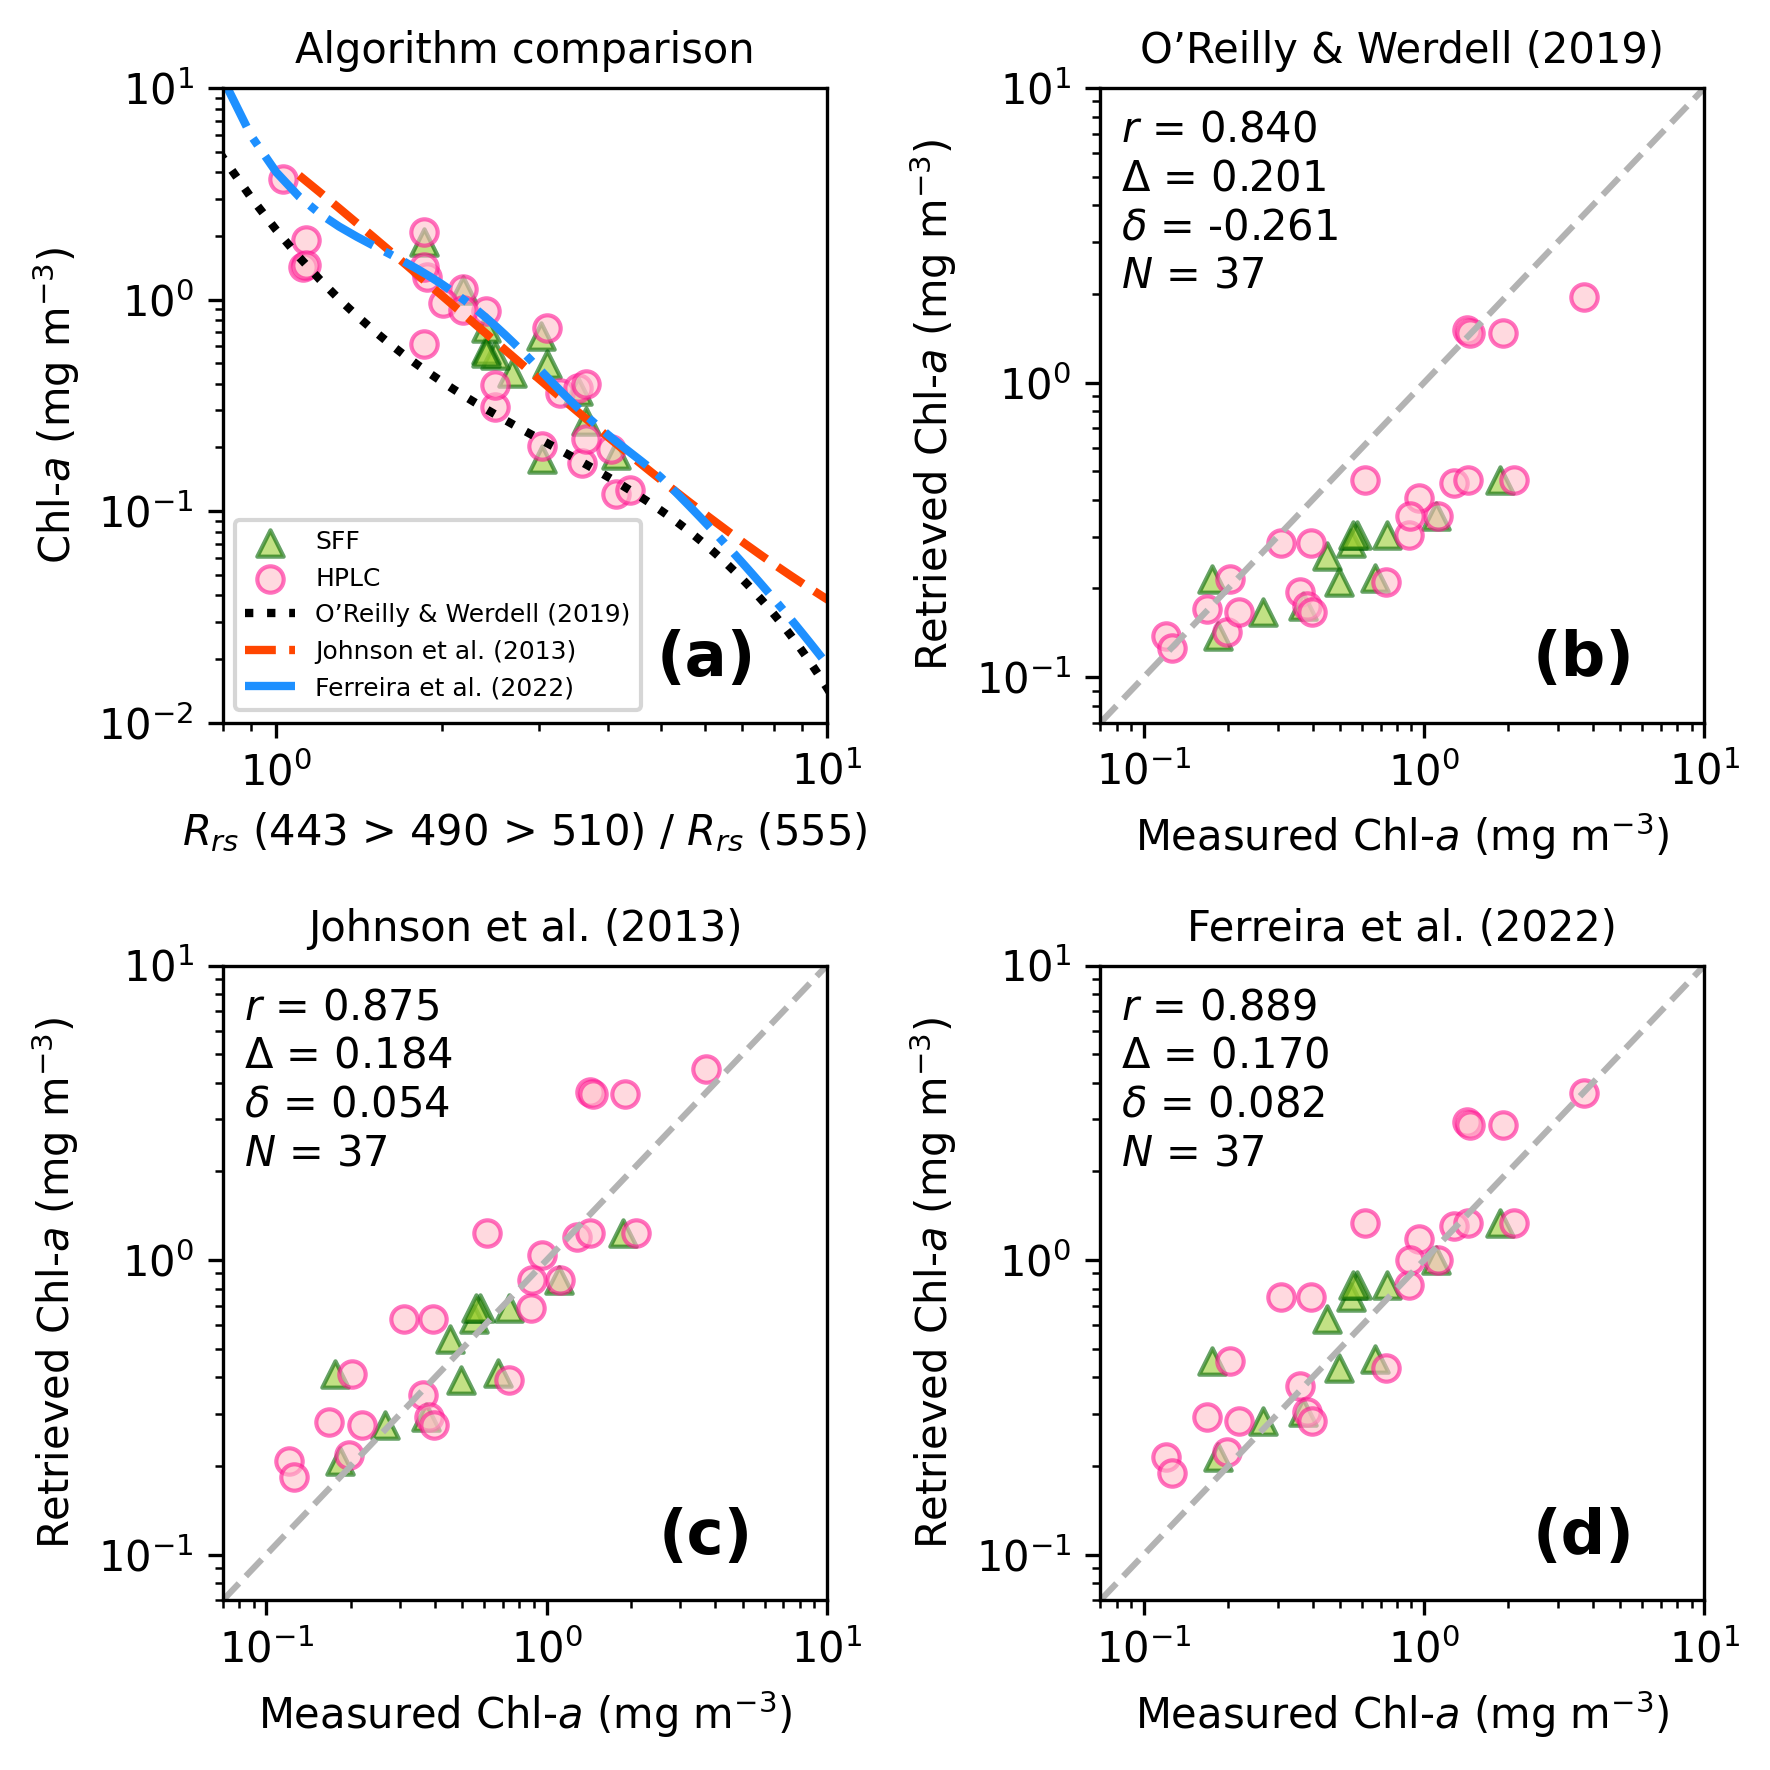

In [9]:
## DEFINE MBR RANGES
mbr_grid = pd.Series(np.linspace(0.1, 100, 1000))

## CALCULATE CHL-A
chla_OW = oc4_seawifs_OW_2019(mbr_grid)
chla_Johnson = oc4_seawifs_Johnson_2013(mbr_grid)
chla_Ferreira = oc4_seawifs_Ferreira_2022(mbr_grid)

## SET CHL-A RANGE FOR EACH MODEL
mask_OW = (chla_OW >= 0.01) & (chla_OW <= 100)
mask_Johnson = (chla_Johnson >= 0.01) & (chla_Johnson <= 4)
mask_Ferreira = (chla_Ferreira >= 0.02) & (chla_Ferreira <= 17)

## FILTER MBR AND CHL-A
mbr_OW_plot = mbr_grid[mask_OW]
chla_OW_plot = chla_OW[mask_OW]
mbr_Johnson_plot = mbr_grid[mask_Johnson]
chla_Johnson_plot = chla_Johnson[mask_Johnson]
mbr_Ferreira_plot = mbr_grid[mask_Ferreira]
chla_Ferreira_plot = chla_Ferreira[mask_Ferreira]

## GET DATA FOR PLOT
chl_ALL = pd.DataFrame({"sff": df['total_chla_sff'],"hplc": df_hplc['total_chla_hplc']})
chla_OC_VAL = pd.DataFrame({"sff": oc4_seawifs_OW_2019(df['MBR']),
                            "hplc": oc4_seawifs_OW_2019(df_hplc['MBR'])})
chla_JO_VAL = pd.DataFrame({"sff": oc4_seawifs_Johnson_2013(df['MBR']),
                            "hplc": oc4_seawifs_Johnson_2013(df_hplc['MBR'])})
chla_FE_VAL = pd.DataFrame({"sff": oc4_seawifs_Ferreira_2022(df['MBR']),
                            "hplc": oc4_seawifs_Ferreira_2022(df_hplc['MBR'])})

## GET DATA FOR INPUT TO STATS
chl_ALL2 = pd.concat([df['total_chla_sff'],df_hplc['total_chla_hplc']]).astype(float).reset_index(drop=True)
chla_OC_VAL2 = pd.concat([oc4_seawifs_OW_2019(df['MBR']),
                          oc4_seawifs_OW_2019(df_hplc['MBR'])]).astype(float).reset_index(drop=True)
chla_JO_VAL2 = pd.concat([oc4_seawifs_Johnson_2013(df['MBR']),
                          oc4_seawifs_Johnson_2013(df_hplc['MBR'])]).astype(float).reset_index(drop=True)
chla_FE_VAL2 = pd.concat([oc4_seawifs_Ferreira_2022(df['MBR']),
                          oc4_seawifs_Ferreira_2022(df_hplc['MBR'])]).astype(float).reset_index(drop=True)

## COMPUTE STATS
error_O9 = errortest_log(chl_ALL2, chla_OC_VAL2)
error_JO = errortest_log(chl_ALL2, chla_JO_VAL2)
error_FE = errortest_log(chl_ALL2, chla_FE_VAL2)

## SETUP PLOT
fig, axes = plt.subplots(2, 2, figsize=(6, 6), dpi=300)
axes = axes.flatten()
panel_labels = list(string.ascii_lowercase[4:])  # start at 'e' if needed
xlim = [0.07, 10]
ylim = [0.07, 10]

## (a) MBA PLOT
ax = axes[0]
ax.scatter(df['MBR'],df['total_chla_sff'],marker='^',facecolors='yellowgreen',edgecolors='darkgreen', s=40,
           alpha=0.6, label='SFF')
ax.scatter(df_hplc['MBR'], df_hplc['total_chla_hplc'],marker='o', facecolors='pink',edgecolors='deeppink', s=40,
           alpha=0.6, label='HPLC')
ax.plot(mbr_OW_plot, chla_OW_plot, ':', c='black', lw=2,label='O’Reilly & Werdell (2019)')
ax.plot(mbr_Johnson_plot, chla_Johnson_plot, '--', c='orangered', lw=2,label='Johnson et al. (2013)')
ax.plot(mbr_Ferreira_plot, chla_Ferreira_plot, '-.', c='dodgerblue', lw=2,label='Ferreira et al. (2022)')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim([0.01, 10])
ax.set_xlim([0.8, 10])
ax.set_title(f'Algorithm comparison', fontsize=10)
ax.set_ylabel('Chl-$a$ (mg m$^{-3}$)', fontsize=10)
ax.set_xlabel(r'$R_{rs}$ (443 > 490 > 510) / $R_{rs}$ (555)', fontsize=10)
ax.legend(fontsize=6, loc='lower left')
axes[0].text(0.8, 0.1, "(a)",transform=axes[0].transAxes,fontsize=15,fontweight="bold",va="center", ha="center")

## (b) OC4
plot_validation(axes[1],chl_ALL,chla_OC_VAL,'O’Reilly & Werdell (2019)','OC4')
text = (f"$r$ = {error_O9[0]:.3f}\n" f"$\\Delta$ = {error_O9[7]:.3f}\n" f"$\\delta$ = {error_O9[2]:.3f}\n"
        f"$N$ = {int(error_O9[5])}")
axes[1].annotate(text,xy=(0, 1),xycoords='axes fraction',xytext=(5, -5),textcoords='offset points',
            ha='left',va='top',fontsize=10)
axes[1].text(0.8, 0.1, "(b)",transform=axes[1].transAxes,fontsize=15,fontweight="bold",va="center", ha="center")

## (c) JOHNSON
plot_validation(axes[2],chl_ALL,chla_JO_VAL,'Johnson et al. (2013)','Johnson')
text = (f"$r$ = {error_JO[0]:.3f}\n" f"$\\Delta$ = {error_JO[7]:.3f}\n" f"$\\delta$ = {error_JO[2]:.3f}\n"
        f"$N$ = {int(error_JO[5])}")
axes[2].annotate(text,xy=(0, 1),xycoords='axes fraction',xytext=(5, -5),textcoords='offset points',
            ha='left',va='top',fontsize=10)
axes[2].text(0.8, 0.1, "(c)",transform=axes[2].transAxes,fontsize=15,fontweight="bold",va="center", ha="center")

## (d) FERREIRA
plot_validation(axes[3],chl_ALL,chla_FE_VAL,'Ferreira et al. (2022)','Ferreira')
text = (f"$r$ = {error_FE[0]:.3f}\n" f"$\\Delta$ = {error_FE[7]:.3f}\n" f"$\\delta$ = {error_FE[2]:.3f}\n"
        f"$N$ = {int(error_FE[5])}")
axes[3].annotate(text,xy=(0, 1),xycoords='axes fraction',xytext=(5, -5),textcoords='offset points',ha='left',
            va='top',fontsize=10)
axes[3].text(0.8, 0.1, "(d)",transform=axes[3].transAxes,fontsize=15,fontweight="bold",va="center", ha="center")

## FINAL FORMATTING
for ax in axes:
    ax.tick_params(labelsize=10)
fig.tight_layout()
plt.show()

## STEP 10: Figure 4 box plots data

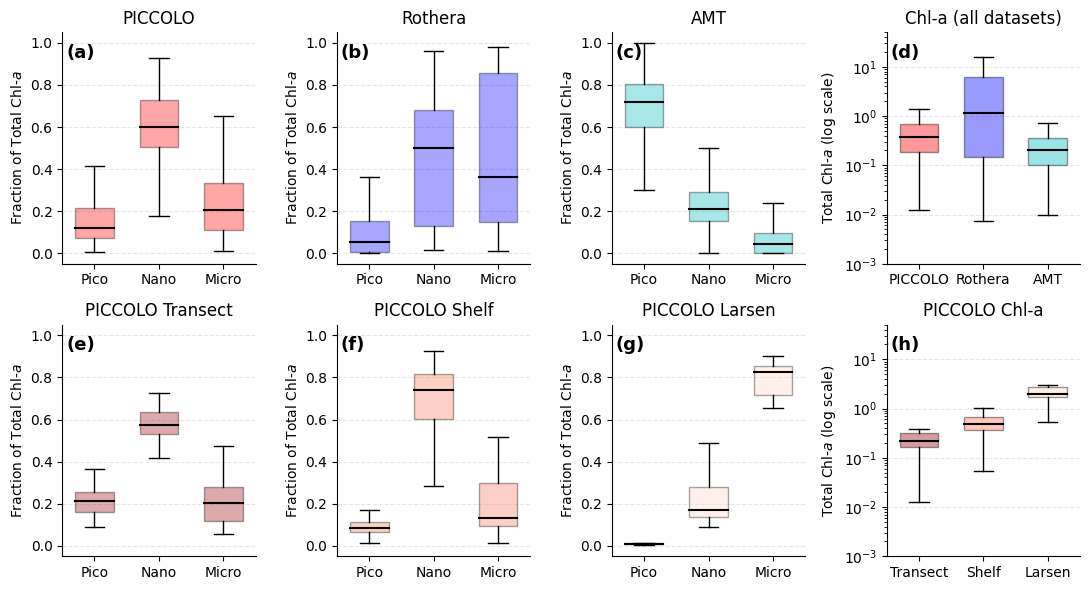

In [10]:
## 1. COMPUTE FRACTIONS
## PICCOLO
df["Fp"] = df["pico_chla_sff"] / df["total_chla_sff"]
df["Fn"] = df["nano_chla_sff"] / df["total_chla_sff"]
df["Fm"] = df["micro_chla_sff"] / df["total_chla_sff"]
## ROTHERA
Fp_Rothera = PICO_CHL_ROTHERA / TOTAL_CHL_ROTHERA
Fn_Rothera = NANO_CHL_ROTHERA / TOTAL_CHL_ROTHERA
Fm_Rothera = MICRO_CHL_ROTHERA / TOTAL_CHL_ROTHERA
## AMT
Fp_AMT = PICO_CHL_AMT / TOTAL_CHL_AMT
Fn_AMT = NANO_CHL_AMT / TOTAL_CHL_AMT
Fm_AMT = MICRO_CHL_AMT / TOTAL_CHL_AMT

## 2. LABELS AND COLOURS
## FRACTION LABELS
fraction_labels = ["Pico", "Nano", "Micro"]
## DATASET COLOURS
dataset_colors = {"PICCOLO": "r","Rothera": "b","AMT": "c"}
## COLOURS SCALES 
cmap = mpl.cm.Reds
label_colors = {1: cmap(0.45),2: cmap(0.15),3: cmap(0.90)}
## REORDER WITH INCREASING CHL-A
label_colors2 = {1: cmap(0.90),2: cmap(0.45),3: cmap(0.15)}
## LABEL NAMES
label_names = {1: "PICCOLO Shelf",2: "PICCOLO Larsen",3: "PICCOLO Transect"}

## 3. DROP NANS
piccolo_data = [df["Fp"].dropna(),df["Fn"].dropna(),df["Fm"].dropna()]
rothera_data = [pd.Series(Fp_Rothera).dropna(),pd.Series(Fn_Rothera).dropna(),pd.Series(Fm_Rothera).dropna()]
amt_data = [pd.Series(Fp_AMT).dropna(),pd.Series(Fn_AMT).dropna(),pd.Series(Fm_AMT).dropna()]
datasets = [("PICCOLO", piccolo_data),("Rothera", rothera_data),("AMT", amt_data)]

## 4. SETUIP FIGURE
plt.rcParams.update({"font.size": 10,"axes.spines.top": False,"axes.spines.right": False})
panel_labels = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)", "(g)", "(h)"]
fig, axes = plt.subplots(2, 4, figsize=(11, 6), sharey=False)

## 5. TOP ROW FRACTIONS
for i, (title, data) in enumerate(datasets):
    ax = axes[0, i]
    color = dataset_colors[title]
    bp = ax.boxplot(data,patch_artist=True,widths=0.6,showfliers=False)
    for box in bp["boxes"]:
        box.set_facecolor(color)
        box.set_alpha(0.35)
        box.set_edgecolor("black")
    for med in bp["medians"]:
        med.set_color("black")
        med.set_linewidth(1.5)
    ax.set_title(title, fontsize=12)
    ax.set_xticklabels(fraction_labels)
    # Unchanged fraction axis
    ax.set_ylim(-0.05, 1.05)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.set_ylabel("Fraction of Total Chl-$a$")

## 6. TOP RIGHT: CHL-A (ALL DATA)
ax = axes[0, 3]
chl_top = [df["total_chla_sff"].dropna(),pd.Series(TOTAL_CHL_ROTHERA).dropna(),pd.Series(TOTAL_CHL_AMT).dropna()]
bp = ax.boxplot(chl_top,patch_artist=True,widths=0.6,showfliers=False)
for i, box in enumerate(bp["boxes"]):
    box.set_facecolor(list(dataset_colors.values())[i])
    box.set_alpha(0.4)
    box.set_edgecolor("black")
for med in bp["medians"]:
    med.set_color("black")
    med.set_linewidth(1.5)      
ax.set_xticklabels(["PICCOLO", "Rothera", "AMT"])
ax.set_yscale("log")
ax.set_ylim(0.001, 50)
ax.set_ylabel("Total Chl-$a$ (log scale)")
ax.set_title("Chl-a (all datasets)")
ax.grid(axis="y", linestyle="--", alpha=0.3)

## 7. BOTTOM ROW (PICCOLO SUBREGIONS)
for i, label in enumerate([3, 1, 2]):
    ax = axes[1, i]
    subset = df[df["Labels"] == label]
    data = [subset["Fp"].dropna(),subset["Fn"].dropna(),subset["Fm"].dropna()]
    color = label_colors[label]
    bp = ax.boxplot(data,patch_artist=True,widths=0.6,showfliers=False)
    for box in bp["boxes"]:
        box.set_facecolor(color)
        box.set_alpha(0.35)
        box.set_edgecolor("black")
    for med in bp["medians"]:
        med.set_color("black")
        med.set_linewidth(1.5)
    ax.set_xticklabels(fraction_labels)
    # Unchanged fraction axis
    ax.set_ylim(-0.05, 1.05)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.set_title(label_names[label])
    ax.set_ylabel("Fraction of Total Chl-$a$")

## 8. BOTTOM RIGHT: PICCOLO CHL-A
ax = axes[1, 3]
chl_bottom = [df[df["Labels"] == 3]["total_chla_sff"].dropna(),df[df["Labels"] == 1]["total_chla_sff"].dropna(),
              df[df["Labels"] == 2]["total_chla_sff"].dropna()]
bp = ax.boxplot(chl_bottom,patch_artist=True,widths=0.6,showfliers=False)
for i, box in enumerate(bp["boxes"]):
    box.set_facecolor(list(label_colors2.values())[i])
    box.set_alpha(0.4)
    box.set_edgecolor("black")
for med in bp["medians"]:
    med.set_color("black")
    med.set_linewidth(1.5)
ax.set_xticklabels(["Transect", "Shelf", "Larsen"])
ax.set_yscale("log")
ax.set_ylim(0.001, 50)
ax.set_ylabel("Total Chl-$a$ (log scale)")
ax.set_title("PICCOLO Chl-a")
ax.grid(axis="y", linestyle="--", alpha=0.3)

## 9. PANEL LABELS
for i, ax in enumerate(axes.flatten()):
    ax.text(0.02, 0.95,panel_labels[i],transform=ax.transAxes,fontsize=13,fontweight="bold",va="top",ha="left")

## 10. FINAL LAYOUT
plt.tight_layout()
plt.show()

## STEP 11: Fit three-component model to data

### Fit PICCOLO

In [11]:
## PICO
params   = Parameters()
params.add('Cm1', value= 0.2)                           ## Initial guess for parameters
params.add('D1', value= 0.5, min = 0.001, max = 0.999) ## Initial guess for parameters
X        = df["pico_chla_sff"]/df["total_chla_sff"] ## Define inputs X 
Y        = df["total_chla_sff"]          ## Define inputs Y
out      = Minimizer(Three_com_mod_PICO, params, fcn_args=(X, Y))# Fit function
result   = out.minimize()
print("-------PICCOLO PICO-PLANKTON MODEL--------") # Print function results 
report_fit(result) # Print function results 
Cm1_PIC   = result.params['Cm1'].value # Extract parameters
D1_PIC    = result.params['D1'].value # Extract parameters
## PICO + NANO
params  = Parameters()
params.add('Cm12', value= 0.2)                          ## Initial guess for parameters
params.add('D12', value= 0.5, min = 0.001, max = 0.999)## Initial guess for parameters
print("-------PICCOLO PICO-NANO-PLANKTON MODEL--------") # Print function results 
X = (df["pico_chla_sff"]+df["nano_chla_sff"] )/df["total_chla_sff"] ## Define inputs X 
Y = df["total_chla_sff"]                     ## Define inputs Y
out = Minimizer(Three_com_mod_NANOPICO, params, fcn_args=(X, Y))# Fit function
result   = out.minimize() 
report_fit(result)# Print function results
Cm12_PIC   = result.params['Cm12'].value# Extract parameters
D12_PIC    = result.params['D12'].value# Extract parameters

-------PICCOLO PICO-PLANKTON MODEL--------
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 16
    # data points      = 133
    # variables        = 2
    chi-square         = 0.83025641
    reduced chi-square = 0.00633784
    Akaike info crit   = -671.157187
    Bayesian info crit = -665.376489
[[Variables]]
    Cm1:  0.07293373 +/- 0.00970242 (13.30%) (init = 0.2)
    D1:   0.28795250 +/- 0.02484621 (8.63%) (init = 0.5)
[[Correlations]] (unreported correlations are < 0.100)
    C(Cm1, D1) = -0.6641
-------PICCOLO PICO-NANO-PLANKTON MODEL--------
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 19
    # data points      = 133
    # variables        = 2
    chi-square         = 4.96898688
    reduced chi-square = 0.03793120
    Akaike info crit   = -433.188710
    Bayesian info crit = -427.408011
[[Variables]]
    Cm12:  1.47728379 +/- 0.29114308 (19.71%) (init = 0.2)
    D12:   0.84919703 +/- 0.02907425 (3.42%) (init = 0.5)
[[Cor

### Fit ROTHERA

In [12]:
## PICO
params   = Parameters()
params.add('Cm1', value= 0.2)                           ## Initial guess for parameters
params.add('D1', value= 0.5, min = 0.001, max = 0.999) ## Initial guess for parameters
X        = PICO_CHL_ROTHERA/TOTAL_CHL_ROTHERA ## Define inputs X 
Y        = TOTAL_CHL_ROTHERA          ## Define inputs Y
out      = Minimizer(Three_com_mod_PICO, params, fcn_args=(X, Y))# Fit function
result   = out.minimize()
print("-------ROTHERA PICO-PLANKTON MODEL--------") # Print function results 
report_fit(result) # Print function results 
Cm1_ROT   = result.params['Cm1'].value # Extract parameters
D1_ROT    = result.params['D1'].value # Extract parameters
## PICO + NANO
params  = Parameters()
params.add('Cm12', value= 0.2)                          ## Initial guess for parameters
params.add('D12', value= 0.5, min = 0.001, max = 0.999)## Initial guess for parameters
print("-------ROTHERA PICO-NANO-PLANKTON MODEL--------") # Print function results 
X = (PICO_CHL_ROTHERA+NANO_CHL_ROTHERA)/TOTAL_CHL_ROTHERA ## Define inputs X 
Y = TOTAL_CHL_ROTHERA                     ## Define inputs Y
out = Minimizer(Three_com_mod_NANOPICO, params, fcn_args=(X, Y))# Fit function
result   = out.minimize() 
report_fit(result)# Print function results
Cm12_ROT   = result.params['Cm12'].value# Extract parameters
D12_ROT    = result.params['D12'].value# Extract parameters

-------ROTHERA PICO-PLANKTON MODEL--------
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 16
    # data points      = 742
    # variables        = 2
    chi-square         = 3.23539335
    reduced chi-square = 0.00437215
    Akaike info crit   = -4028.91746
    Bayesian info crit = -4019.69876
[[Variables]]
    Cm1:  0.09807913 +/- 0.00889253 (9.07%) (init = 0.2)
    D1:   0.18861712 +/- 0.00533063 (2.83%) (init = 0.5)
[[Correlations]] (unreported correlations are < 0.100)
    C(Cm1, D1) = -0.4510
-------ROTHERA PICO-NANO-PLANKTON MODEL--------
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 16
    # data points      = 742
    # variables        = 2
    chi-square         = 26.9064825
    reduced chi-square = 0.03636011
    Akaike info crit   = -2457.20064
    Bayesian info crit = -2447.98195
[[Variables]]
    Cm12:  1.29789746 +/- 0.06924236 (5.33%) (init = 0.2)
    D12:   0.84370095 +/- 0.01205849 (1.43%) (init = 0.5)
[[Corre

### Fit AMT

In [13]:
## PICO
params   = Parameters()
params.add('Cm1', value= 0.2)                           ## Initial guess for parameters
params.add('D1', value= 0.5, min = 0.001, max = 0.999) ## Initial guess for parameters
X        = PICO_CHL_AMT/TOTAL_CHL_AMT ## Define inputs X 
Y        = TOTAL_CHL_AMT          ## Define inputs Y
## Removing Nans
ASD = np.where(X >= 0)
X        = X[ASD]
Y        = Y[ASD]
out      = Minimizer(Three_com_mod_PICO, params, fcn_args=(X, Y))# Fit function
result   = out.minimize()
print("-------AMT PICO-PLANKTON MODEL--------") # Print function results 
report_fit(result) # Print function results 
Cm1_AMT   = result.params['Cm1'].value # Extract parameters
D1_AMT    = result.params['D1'].value # Extract parameters
## PICO + NANO
params  = Parameters()
params.add('Cm12', value= 0.2)                          ## Initial guess for parameters
params.add('D12', value= 0.5, min = 0.001, max = 0.999)## Initial guess for parameters
print("-------AMT PICO-NANO-PLANKTON MODEL--------") # Print function results 
X = (PICO_CHL_AMT+NANO_CHL_AMT)/TOTAL_CHL_AMT ## Define inputs X 
Y = TOTAL_CHL_AMT                     ## Define inputs Y
## Removing Nans
ASD = np.where(X >= 0)
X        = X[ASD]
Y        = Y[ASD]
out = Minimizer(Three_com_mod_NANOPICO, params, fcn_args=(X, Y))# Fit function
result   = out.minimize() 
report_fit(result)# Print function results
Cm12_AMT   = result.params['Cm12'].value# Extract parameters
D12_AMT    = result.params['D12'].value# Extract parameters

-------AMT PICO-PLANKTON MODEL--------
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 19
    # data points      = 1476
    # variables        = 2
    chi-square         = 46.4756516
    reduced chi-square = 0.03153029
    Akaike info crit   = -5100.24778
    Bayesian info crit = -5089.65359
[[Variables]]
    Cm1:  1.09197495 +/- 0.08864791 (8.12%) (init = 0.2)
    D1:   0.74709985 +/- 0.00718258 (0.96%) (init = 0.5)
[[Correlations]] (unreported correlations are < 0.100)
    C(Cm1, D1) = -0.6479
-------AMT PICO-NANO-PLANKTON MODEL--------
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 22
    # data points      = 769
    # variables        = 2
    chi-square         = 12.8575167
    reduced chi-square = 0.01676339
    Akaike info crit   = -3142.10387
    Bayesian info crit = -3132.81368
[[Variables]]
    Cm12:  2.58937542 +/- 0.18567819 (7.17%) (init = 0.2)
    D12:   0.96638084 +/- 0.00670617 (0.69%) (init = 0.5)
[[Correlations

## STEP 12: Figure 5 Results from the three-component model

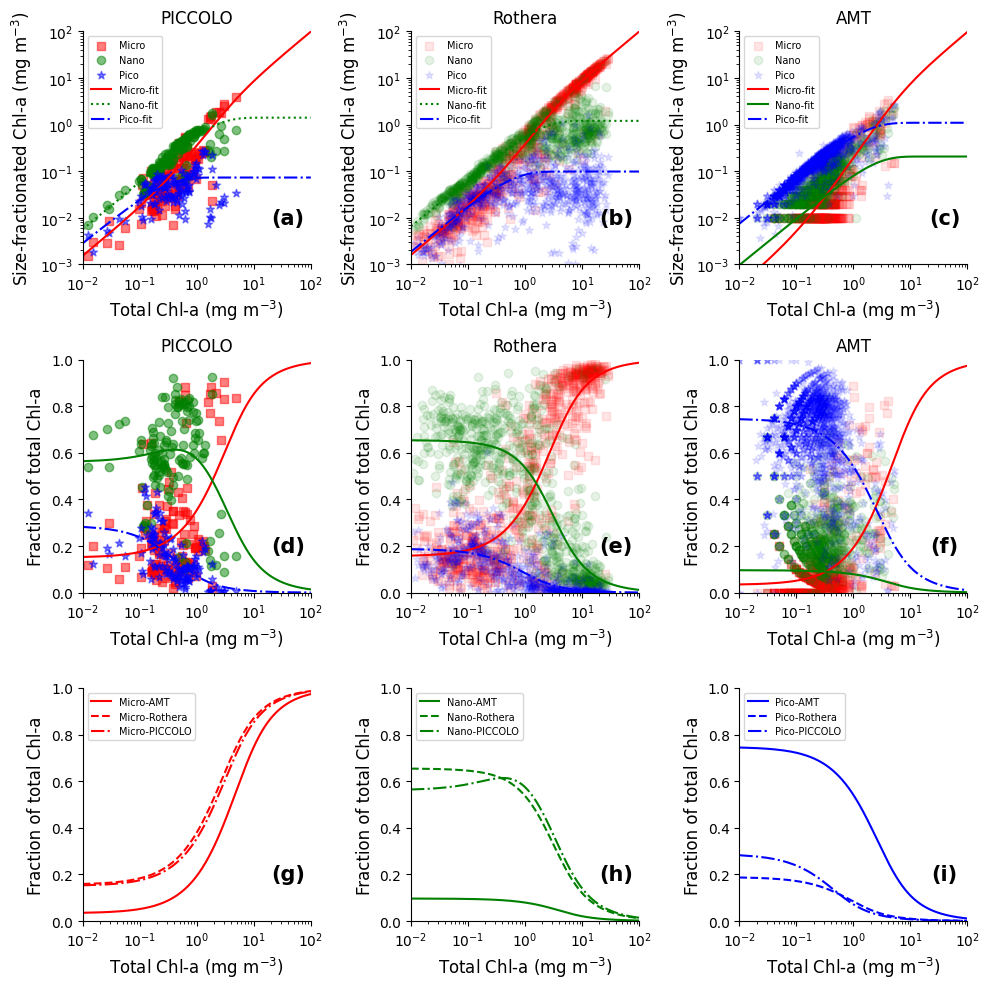

In [14]:
## SORT PICCOLO DATA
MICRO_CHL_PICCOLO    = df["micro_chla_sff"]
NANO_CHL_PICCOLO     = df["nano_chla_sff"]
PICO_CHL_PICCOLO     = df["pico_chla_sff"]
TOTAL_CHL_PICCOLO    = df["total_chla_sff"]   

## SIMULATE MODEL WITH PARAMETERS
CHL_SIM              = np.linspace(0.01,100,10000)
## PICCOLO
PICO_CHL_SIM_P         = Cm1_PIC*(1-np.exp(-(D1_PIC/Cm1_PIC)*CHL_SIM))
PICO_NANO_CHL_SIM_P    = Cm12_PIC*(1-np.exp(-(D12_PIC/Cm12_PIC)*CHL_SIM))
MICRO_CHL_SIM_P        = CHL_SIM - PICO_NANO_CHL_SIM_P
NANO_CHL_SIM_P         = PICO_NANO_CHL_SIM_P - PICO_CHL_SIM_P
## ROTHERA
PICO_CHL_SIM_R         = Cm1_ROT*(1-np.exp(-(D1_ROT/Cm1_ROT)*CHL_SIM))
PICO_NANO_CHL_SIM_R    = Cm12_ROT*(1-np.exp(-(D12_ROT/Cm12_ROT)*CHL_SIM))
MICRO_CHL_SIM_R        = CHL_SIM - PICO_NANO_CHL_SIM_R
NANO_CHL_SIM_R         = PICO_NANO_CHL_SIM_R - PICO_CHL_SIM_R
## AMT
PICO_CHL_SIM_A         = Cm1_AMT*(1-np.exp(-(D1_AMT/Cm1_AMT)*CHL_SIM))
PICO_NANO_CHL_SIM_A    = Cm12_AMT*(1-np.exp(-(D12_AMT/Cm12_AMT)*CHL_SIM))
MICRO_CHL_SIM_A        = CHL_SIM - PICO_NANO_CHL_SIM_A
NANO_CHL_SIM_A         = PICO_NANO_CHL_SIM_R - PICO_CHL_SIM_A

## DEFINE PLOT
fig, ([ax1, ax2, ax3], [ax4, ax5, ax6], [ax7, ax8, ax9]) = plt.subplots(3,3, figsize=(10,10))

## SUBPLOT 1
ax1.scatter(TOTAL_CHL_PICCOLO,MICRO_CHL_PICCOLO,color = 'r',  marker = 's', label = 'Micro', alpha=0.5)
ax1.scatter(TOTAL_CHL_PICCOLO,NANO_CHL_PICCOLO,color = 'g',  marker = 'o', label = 'Nano', alpha=0.5)
ax1.scatter(TOTAL_CHL_PICCOLO,PICO_CHL_PICCOLO,color = 'b',  marker = '*', label = 'Pico', alpha=0.5)
ax1.plot(CHL_SIM,MICRO_CHL_SIM_P,color = 'r',  linestyle='solid', label = 'Micro-fit', alpha=1.0)
ax1.plot(CHL_SIM,NANO_CHL_SIM_P,color = 'g',  linestyle=':', label = 'Nano-fit', alpha=1.0)
ax1.plot(CHL_SIM,PICO_CHL_SIM_P,color = 'b',  linestyle='-.', label = 'Pico-fit', alpha=1.0)
ax1.set_xlabel('Total Chl-a (mg m$^{-3}$)', fontsize=12)  
ax1.set_ylabel('Size-fractionated Chl-a (mg m$^{-3}$)', fontsize=12) 
ax1.set_title("PICCOLO", fontsize=12)
ax1.legend(loc="upper left", fontsize=7)
ax1.set_axisbelow(True)
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)
ax1.set_yscale('log')
ax1.set_xscale('log')
ax1.set_xlim(0.01, 100)
ax1.set_ylim(0.001, 100)
ax1.text(0.9, 0.2, "(a)",transform=ax1.transAxes,fontsize=15,fontweight="bold",va="center", ha="center")

## SUBPLOT 2
ax2.scatter(TOTAL_CHL_ROTHERA,MICRO_CHL_ROTHERA,color = 'r',  marker = 's', label = 'Micro', alpha=0.1)
ax2.scatter(TOTAL_CHL_ROTHERA,NANO_CHL_ROTHERA,color = 'g',  marker = 'o', label = 'Nano', alpha=0.1)
ax2.scatter(TOTAL_CHL_ROTHERA,PICO_CHL_ROTHERA,color = 'b',  marker = '*', label = 'Pico', alpha=0.1)
ax2.plot(CHL_SIM,MICRO_CHL_SIM_R,color = 'r',  linestyle='solid', label = 'Micro-fit', alpha=1.0)
ax2.plot(CHL_SIM,NANO_CHL_SIM_R,color = 'g',  linestyle=':', label = 'Nano-fit', alpha=1.0)
ax2.plot(CHL_SIM,PICO_CHL_SIM_R,color = 'b',  linestyle='-.', label = 'Pico-fit', alpha=1.0)
ax2.set_xlabel('Total Chl-a (mg m$^{-3}$)', fontsize=12)  
ax2.set_ylabel('Size-fractionated Chl-a (mg m$^{-3}$)', fontsize=12) 
ax2.legend(loc="upper left", fontsize=7)
ax2.set_title("Rothera", fontsize=12)
ax2.set_axisbelow(True)
ax2.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.set_yscale('log')
ax2.set_xscale('log')
ax2.set_xlim(0.01, 100)
ax2.set_ylim(0.001, 100)
ax2.text(0.9, 0.2, "(b)",transform=ax2.transAxes,fontsize=15,fontweight="bold",va="center", ha="center")

## SUBPLOT 3
ax3.scatter(TOTAL_CHL_AMT,MICRO_CHL_AMT,color = 'r',  marker = 's', label = 'Micro', alpha=0.1)
ax3.scatter(TOTAL_CHL_AMT,NANO_CHL_AMT,color = 'g',  marker = 'o', label = 'Nano', alpha=0.1)
ax3.scatter(TOTAL_CHL_AMT,PICO_CHL_AMT,color = 'b',  marker = '*', label = 'Pico', alpha=0.1)
ax3.plot(CHL_SIM,MICRO_CHL_SIM_A,color = 'r',  linestyle='solid', label = 'Micro-fit', alpha=1.0)
ax3.plot(CHL_SIM,NANO_CHL_SIM_A,color = 'g',  linestyle='-', label = 'Nano-fit', alpha=1.0)
ax3.plot(CHL_SIM,PICO_CHL_SIM_A,color = 'b',  linestyle='-.', label = 'Pico-fit', alpha=1.0)
ax3.set_xlabel('Total Chl-a (mg m$^{-3}$)', fontsize=12)  
ax3.set_ylabel('Size-fractionated Chl-a (mg m$^{-3}$)', fontsize=12) 
ax3.legend(loc="upper left", fontsize=7)
ax3.set_title("AMT", fontsize=12)
ax3.set_axisbelow(True)
ax3.spines['right'].set_visible(False)
ax3.spines['top'].set_visible(False)
ax3.set_yscale('log')
ax3.set_xscale('log')
ax3.set_xlim(0.01, 100)
ax3.set_ylim(0.001, 100)
ax3.text(0.9, 0.2, "(c)",transform=ax3.transAxes,fontsize=15,fontweight="bold",va="center", ha="center")

## SUBPLOT 4
ax4.scatter(TOTAL_CHL_PICCOLO,MICRO_CHL_PICCOLO/TOTAL_CHL_PICCOLO,color = 'r',  marker = 's', label = 'Micro', alpha=0.5)
ax4.scatter(TOTAL_CHL_PICCOLO,NANO_CHL_PICCOLO/TOTAL_CHL_PICCOLO,color = 'g',  marker = 'o', label = 'Nano', alpha=0.5)
ax4.scatter(TOTAL_CHL_PICCOLO,PICO_CHL_PICCOLO/TOTAL_CHL_PICCOLO,color = 'b',  marker = '*', label = 'Pico', alpha=0.5)
ax4.plot(CHL_SIM,MICRO_CHL_SIM_P/CHL_SIM,color = 'r',  linestyle='solid', label = 'Micro-fit', alpha=1.0)
ax4.plot(CHL_SIM,NANO_CHL_SIM_P/CHL_SIM,color = 'g',  linestyle='-', label = 'Nano-fit', alpha=1.0)
ax4.plot(CHL_SIM,PICO_CHL_SIM_P/CHL_SIM,color = 'b',  linestyle='-.', label = 'Pico-fit', alpha=1.0)
ax4.set_xlabel('Total Chl-a (mg m$^{-3}$)', fontsize=12)  
ax4.set_ylabel('Fraction of total Chl-a', fontsize=12) 
ax4.set_title("PICCOLO", fontsize=12)
ax4.set_axisbelow(True)
ax4.spines['right'].set_visible(False)
ax4.spines['top'].set_visible(False)
ax4.set_xscale('log')
ax4.set_xlim(0.01, 100)
ax4.set_ylim(0.0, 1)
ax4.text(0.9, 0.2, "(d)",transform=ax4.transAxes,fontsize=15,fontweight="bold",va="center", ha="center")

## SUBPLOT 5
ax5.scatter(TOTAL_CHL_ROTHERA,MICRO_CHL_ROTHERA/TOTAL_CHL_ROTHERA,color = 'r',  marker = 's', label = 'Micro', alpha=0.1)
ax5.scatter(TOTAL_CHL_ROTHERA,NANO_CHL_ROTHERA/TOTAL_CHL_ROTHERA,color = 'g',  marker = 'o', label = 'Nano', alpha=0.1)
ax5.scatter(TOTAL_CHL_ROTHERA,PICO_CHL_ROTHERA/TOTAL_CHL_ROTHERA,color = 'b',  marker = '*', label = 'Pico', alpha=0.1)
ax5.plot(CHL_SIM,MICRO_CHL_SIM_R/CHL_SIM,color = 'r',  linestyle='solid', label = 'Micro-fit', alpha=1.0)
ax5.plot(CHL_SIM,NANO_CHL_SIM_R/CHL_SIM,color = 'g',  linestyle='-', label = 'Nano-fit', alpha=1.0)
ax5.plot(CHL_SIM,PICO_CHL_SIM_R/CHL_SIM,color = 'b',  linestyle='-.', label = 'Pico-fit', alpha=1.0)
ax5.set_xlabel('Total Chl-a (mg m$^{-3}$)', fontsize=12)  
ax5.set_ylabel('Fraction of total Chl-a', fontsize=12) 
ax5.set_title("Rothera", fontsize=12)
ax5.set_axisbelow(True)
ax5.spines['right'].set_visible(False)
ax5.spines['top'].set_visible(False)
ax5.set_xscale('log')
ax5.set_xlim(0.01, 100)
ax5.set_ylim(0.0, 1)
ax5.text(0.9, 0.2, "(e)",transform=ax5.transAxes,fontsize=15,fontweight="bold",va="center", ha="center")

## SUBPLOT 6
ax6.scatter(TOTAL_CHL_AMT,MICRO_CHL_AMT/TOTAL_CHL_AMT,color = 'r',  marker = 's', label = 'Micro', alpha=0.1)
ax6.scatter(TOTAL_CHL_AMT,NANO_CHL_AMT/TOTAL_CHL_AMT,color = 'g',  marker = 'o', label = 'Nano', alpha=0.1)
ax6.scatter(TOTAL_CHL_AMT,PICO_CHL_AMT/TOTAL_CHL_AMT,color = 'b',  marker = '*', label = 'Pico', alpha=0.1)
ax6.plot(CHL_SIM,MICRO_CHL_SIM_A/CHL_SIM,color = 'r',  linestyle='solid', label = 'Micro-fit', alpha=1.0)
ax6.plot(CHL_SIM,NANO_CHL_SIM_A/CHL_SIM,color = 'g',  linestyle='-', label = 'Nano-fit', alpha=1.0)
ax6.plot(CHL_SIM,PICO_CHL_SIM_A/CHL_SIM,color = 'b',  linestyle='-.', label = 'Pico-fit', alpha=1.0)
ax6.set_xlabel('Total Chl-a (mg m$^{-3}$)', fontsize=12)  
ax6.set_ylabel('Fraction of total Chl-a', fontsize=12) 
ax6.set_title("AMT", fontsize=12)
ax6.set_axisbelow(True)
ax6.spines['right'].set_visible(False)
ax6.spines['top'].set_visible(False)
ax6.set_xscale('log')
ax6.set_xlim(0.01, 100)
ax6.set_ylim(0.0, 1)
ax6.text(0.9, 0.2, "(f)",transform=ax6.transAxes,fontsize=15,fontweight="bold",va="center",ha="center")

## SUBPLOT 7
ax7.plot(CHL_SIM,MICRO_CHL_SIM_A/CHL_SIM,color = 'r',  linestyle='solid', label = 'Micro-AMT', alpha=1.0)
ax7.plot(CHL_SIM,MICRO_CHL_SIM_R/CHL_SIM,color = 'r',  linestyle='--', label = 'Micro-Rothera', alpha=1.0)
ax7.plot(CHL_SIM,MICRO_CHL_SIM_P/CHL_SIM,color = 'r',  linestyle='-.', label = 'Micro-PICCOLO', alpha=1.0)
ax7.set_xlabel('Total Chl-a (mg m$^{-3}$)', fontsize=12)  
ax7.set_ylabel('Fraction of total Chl-a', fontsize=12) 
ax7.set_axisbelow(True)
ax7.spines['right'].set_visible(False)
ax7.spines['top'].set_visible(False)
ax7.set_xscale('log')
ax7.set_xlim(0.01, 100)
ax7.set_ylim(0.0, 1)
ax7.legend(loc="upper left", fontsize=7)
ax7.text(0.9, 0.2, "(g)",transform=ax7.transAxes,fontsize=15,fontweight="bold",va="center", ha="center")

## SUBPLOT 8
ax8.plot(CHL_SIM,NANO_CHL_SIM_A/CHL_SIM,color = 'g',  linestyle='solid', label = 'Nano-AMT', alpha=1.0)
ax8.plot(CHL_SIM,NANO_CHL_SIM_R/CHL_SIM,color = 'g',  linestyle='--', label = 'Nano-Rothera', alpha=1.0)
ax8.plot(CHL_SIM,NANO_CHL_SIM_P/CHL_SIM,color = 'g',  linestyle='-.', label = 'Nano-PICCOLO', alpha=1.0)
ax8.set_xlabel('Total Chl-a (mg m$^{-3}$)', fontsize=12)  
ax8.set_ylabel('Fraction of total Chl-a', fontsize=12) 
ax8.set_axisbelow(True)
ax8.spines['right'].set_visible(False)
ax8.spines['top'].set_visible(False)
ax8.set_xscale('log')
ax8.set_xlim(0.01, 100)
ax8.set_ylim(0.0, 1)
ax8.legend(loc="upper left", fontsize=7)
ax8.text(0.9, 0.2, "(h)",transform=ax8.transAxes,fontsize=15,fontweight="bold",va="center", ha="center")

## SUBPLOT 9
ax9.plot(CHL_SIM,PICO_CHL_SIM_A/CHL_SIM,color = 'b',  linestyle='solid', label = 'Pico-AMT', alpha=1.0)
ax9.plot(CHL_SIM,PICO_CHL_SIM_R/CHL_SIM,color = 'b',  linestyle='--', label = 'Pico-Rothera', alpha=1.0)
ax9.plot(CHL_SIM,PICO_CHL_SIM_P/CHL_SIM,color = 'b',  linestyle='-.', label = 'Pico-PICCOLO', alpha=1.0)
ax9.set_xlabel('Total Chl-a (mg m$^{-3}$)', fontsize=12)  
ax9.set_ylabel('Fraction of total Chl-a', fontsize=12) 
ax9.set_axisbelow(True)
ax9.spines['right'].set_visible(False)
ax9.spines['top'].set_visible(False)
ax9.set_xscale('log')
ax9.set_xlim(0.01, 100)
ax9.set_ylim(0.0, 1)
ax9.legend(loc="upper left", fontsize=7)
ax9.text( 0.9, 0.2, "(i)",transform=ax9.transAxes,fontsize=15,fontweight="bold",va="center", ha="center")

## FINAL LAYOUT
plt.tight_layout()
plt.show()   